In [1]:
!pip install roboflow

from google.colab import userdata
api = userdata.get('secretsub4')

from roboflow import Roboflow
rf = Roboflow(api_key=api)
project = rf.workspace("neural-ocean").project("neural_ocean")
version = project.version(3)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...


1. The dataset is things that are not supposed to be in the ocean like plastic so this dataset is used in YOLO models to detect then remove them
2. There are 15 classes they are: plastic, garbage, cellphones, metal, cans, gloves, tire, sunglasses, electronics, gbottle, misc, rod, pbag, pbottle, net
3. dataset is organised in train, test, validation, and yaml is included to show information about the dataset

Part 2

In [2]:
!uv pip install ultralytics opencv-python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
import cv2


Using Python 3.12.13 environment at: /usr
Checked 2 packages in 90ms
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
model = YOLO('yolo26n.pt')

results = model.train(
    data=f'{dataset.location}/data.yaml',
    epochs=60,
    imgsz=640,
    lr0=0.001,
    optimizer='Adam', #SGD took way too long so i switched to adam
    patience=10,
    batch=16,
    name='neural_ocean_detector'
)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Neural_Ocean-3/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=neural_ocean_detector, nbs=64, nms=False, opset=

1. Training params matter because they are custom settings for the model for example number of epochs, learning_rate affect how models perform
2. Image size matters a lot if image size is 320 for example its speed will be fast but detection will be less accurate compared to a high image size like 640 but it will be slower
3. Patience is used to make model stop if there no improvements
4. Optimiser is like tactic used to learn, for example adam adjusts learning after each param and sgd takes small steps
Learning rate determines how big the step of the model in when learning new raw data, if too high then pretty much learns nothing if too low it takes too much time and wastes time, processing power and money

Part 3

In [9]:
results_path = '/content/runs/detect/neural_ocean_detector'

import os

best_path = os.path.join(results_path, 'weights', 'best.pt')
print(best_path)

last_path = os.path.join(results_path, 'weights', 'last.pt')
print(last_path)

/content/runs/detect/neural_ocean_detector/weights/best.pt
/content/runs/detect/neural_ocean_detector/weights/last.pt


1. the best.pt because it is the best performing one
2. You can share and reuse the models with others
3. you can create a variable called best_model and put YOLO('best.pt')

Part 4


image 1/1 /content/pictures/bag.jpg: 448x640 1 pbag, 25.1ms
Speed: 4.7ms preprocess, 25.1ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict


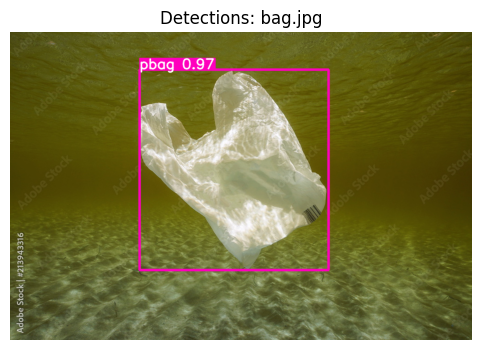


image 1/1 /content/pictures/bottle.webp: 384x640 1 pbottle, 60.2ms
Speed: 9.3ms preprocess, 60.2ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict


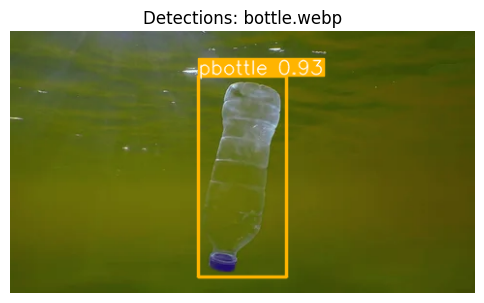


image 1/1 /content/pictures/phone.webp: 384x640 1 cellphone, 22.3ms
Speed: 3.2ms preprocess, 22.3ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict


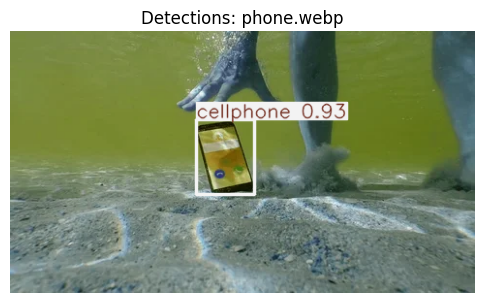

In [19]:
best_model = YOLO('/content/runs/detect/neural_ocean_detector/weights/best.pt')
test_images = [
    '/content/pictures/bag.jpg',
    '/content/pictures/bottle.webp',
    '/content/pictures/phone.webp'
]

for img_path in test_images:
    if not os.path.exists(img_path):
        print(f"Image not found: {img_path}")
    else:
      results = best_model.predict(source=img_path, conf=0.2, save=True)

      for r in results:
        results_plot = r.plot()
        plt.figure(figsize=(6, 4))
        plt.imshow(results_plot)
        plt.axis('off')
        plt.title(f"Detections: {os.path.basename(img_path)}")
        plt.show()



1. This means that if confidence is over for example 0.2 it will only display if the model is is confident with 0.2 or more to display the object
2. poor resolution, blurry, bad lighting
3. Checks if model has overfitted or not, checks if it only memories or it actually knows patterns of the objects

Part 5

In [ ]:
# i downloaded it manually from content files

1. best.pt is best as its the best accuracy precision and overall model
2. Better perforamce
3. You can share it with other co workers